**Phase 10 — GP versus TD-DFT on the external photoswitch holdout**

Notebook `09` established that the published Gaussian Process (GP) transfers poorly to
318 Griffiths photoswitches that were never seen in training, scaling, or hyperparameter
optimisation: RMSE = 77.0 nm, $R^{2}=-0.269$, and a systematic $+53$ nm red shift.

This notebook asks the question `09` left open. The Griffiths table (*Chem. Sci.* 2022)
ships **TD-DFT reference wavelengths for the same E-isomer $\pi\rightarrow\pi^{\ast}$
transition** at four levels of theory: PBE0, TPSSh/6-31G\*\*, CAM-B3LYP/6-31G\*\*, and
BHLYP/6-31G\*. That makes it possible to benchmark the GP against quantum chemistry on a
**genuinely external** set, rather than on the 36-compound Beard subset used in the
manuscript.

**Why this matters.** The manuscript's central claim is that the GP outperforms TD-DFT.
That claim rests on a benchmark whose experimental labels are heterogeneous text-mined
$\lambda_{\max}$ values of unspecified transition character. Here the labels are a single,
well-defined transition and the DFT values were computed *for that transition*. If the
ranking reverses, the manuscript's advantage is an artifact of label definition rather
than a capability difference.

**Fairness caveat, stated up front.** On this holdout TD-DFT is scored on precisely the
transition it computed, while the GP was trained on mixed literature $\lambda_{\max}$ and
has no mechanism to select a transition. The asymmetry favours DFT here exactly as the
reverse asymmetry favoured the GP on the Beard benchmark. Both asymmetries are reported.

**Imports and figure style**

Figures are produced with Matplotlib rather than Plotly because they are intended as
static, high-DPI manuscript panels and must match the style of notebooks `07`–`09`.

In [1]:
from __future__ import annotations

import json
import warnings
from pathlib import Path
from typing import Any

import joblib
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from rdkit import Chem, RDLogger
from rdkit.Chem import AllChem
from rdkit.Chem.MolStandardize import rdMolStandardize
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")
RDLogger.DisableLog("rdApp.*")

mpl.rcParams.update(
    {
        "figure.dpi": 110,
        "savefig.dpi": 300,
        "font.size": 13,
        "axes.labelsize": 14,
        "axes.titlesize": 14,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 11,
        "axes.grid": True,
        "grid.alpha": 0.3,
    }
)

RNG_SEED = 42
print("imports ok")

imports ok


**Rebuild the external holdout, carrying the TD-DFT columns through the curation funnel**

The funnel is identical to notebook `09`: stereo-free, uncharged InChIKey identity against
the curated Beard set ($n$ = 6,878); drop keys already present in Beard; drop rows lacking
an experimental E $\pi\rightarrow\pi^{\ast}$ label; average duplicate structures. The only
change is that the four DFT columns are averaged alongside the experimental label so each
of the 318 unique structures carries whatever theory values exist for it.

The assertion at the end confirms the resulting key set and experimental labels are
identical to `external_validation.csv`, so this notebook cannot silently diverge from `09`.

In [2]:
UNCHARGER = rdMolStandardize.Uncharger()


def mol_from_smiles(smi: Any) -> Chem.Mol | None:
    """Parse and sanitize a SMILES string; return None if invalid."""
    if not isinstance(smi, str) or not smi.strip():
        return None
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    try:
        Chem.SanitizeMol(mol)
    except Exception:
        return None
    return mol


def inchikey_nostereo(smi: Any) -> str | None:
    """Structure identity ignoring E/Z and tetrahedral stereo, matching the OOD filter.

    Photoswitch tables report E and Z isomers of the same azo chromophore as separate
    rows. Stereo-free identity is therefore the correct granularity for asking whether a
    scaffold was already seen during training.
    """
    mol = mol_from_smiles(smi)
    if mol is None:
        return None
    try:
        mol = UNCHARGER.uncharge(mol)
        Chem.SanitizeMol(mol)
    except Exception:
        pass
    Chem.RemoveStereochemistry(mol)
    try:
        return Chem.MolToInchiKey(mol)
    except Exception:
        return None


LABEL = "E isomer pi-pi* wavelength in nm"
DFT_COLS: dict[str, str] = {
    "PBE0": "PBE0 DFT E isomer pi-pi* wavelength in nm",
    "TPSSh/6-31G**": "TPSSh/6-31G** DFT E isomer pi-pi* wavelength in nm",
    "CAM-B3LYP/6-31G**": "CAM-B3LYP/6-31G** DFT E isomer pi-pi* wavelength in nm",
    "BHLYP/6-31G*": "BHLYP/6-31G* DFT E isomer pi-pi* wavelength in nm",
}

ps = pd.read_csv("photoswitches.csv")
beard = pd.read_csv("beard_model_ready_features.csv")
ext = pd.read_csv("external_validation.csv")

beard_keys = set(beard["canonical_smi"].map(inchikey_nostereo).dropna())
ps["inchikey_nostereo"] = ps["SMILES"].map(inchikey_nostereo)
ps["in_beard"] = ps["inchikey_nostereo"].isin(beard_keys)

ood = ps.loc[~ps["in_beard"]].dropna(subset=[LABEL, "inchikey_nostereo"]).copy()
agg: dict[str, str] = {LABEL: "mean"} | {c: "mean" for c in DFT_COLS.values()}
ood_g = ood.groupby("inchikey_nostereo", as_index=False).agg(agg)

df = ext.merge(ood_g, on="inchikey_nostereo", how="left", validate="one_to_one")

print("=== Curation funnel (carrying DFT columns) ===")
print(f"photoswitches.csv rows:                   {len(ps)}")
print(f"rows already in Beard 6,878:              {int(ps['in_beard'].sum())}")
print(f"OOD rows with experimental label:         {len(ood)}")
print(f"unique OOD structures:                    {len(ood_g)}")
print(f"merged against external_validation.csv:   {len(df)}")

assert len(df) == len(ext) == 318, "holdout size changed"
assert set(df["inchikey_nostereo"]) == set(ext["inchikey_nostereo"])
max_dev = float(np.nanmax(np.abs(df["lambda_max_exp_nm"] - df[LABEL])))
assert max_dev < 1e-6, f"experimental labels diverge from notebook 09 ({max_dev})"
print(f"\nlabel agreement with notebook 09: max |diff| = {max_dev:.2e} nm  (identical)")

=== Curation funnel (carrying DFT columns) ===
photoswitches.csv rows:                   405
rows already in Beard 6,878:              66
OOD rows with experimental label:         326
unique OOD structures:                    318
merged against external_validation.csv:   318

label agreement with notebook 09: max |diff| = 0.00e+00 nm  (identical)


**TD-DFT coverage is partial and highly uneven — this bounds every comparison below**

Only a minority of the 318 external structures carry theory values, and the four levels of
theory were not applied to the same molecules. Two functionals cover roughly a third of the
holdout; the other two cover a handful of compounds and cannot support any metric. The
coverage table below is the reason all comparisons in this notebook are reported
**per functional on its own matched subset**, never pooled.

In [3]:
cov_rows: list[dict[str, Any]] = []
for name, col in DFT_COLS.items():
    n = int(df[col].notna().sum())
    cov_rows.append(
        {
            "functional": name,
            "n_with_theory": n,
            "coverage_pct": 100.0 * n / len(df),
            "usable": n >= 30,
        }
    )
coverage = pd.DataFrame(cov_rows)
print("=== TD-DFT coverage on the 318-molecule external holdout ===")
print(coverage.to_string(index=False, float_format=lambda v: f"{v:6.1f}"))

all_four = df.dropna(subset=list(DFT_COLS.values()))
print(f"\nstructures with all four functionals present: {len(all_four)}")

pair = df.dropna(subset=[DFT_COLS["PBE0"], DFT_COLS["CAM-B3LYP/6-31G**"]])
print(f"structures with both PBE0 and CAM-B3LYP:     {len(pair)}")

USABLE = [r["functional"] for r in cov_rows if r["usable"]]
print(f"\nfunctionals retained for metric reporting (n >= 30): {USABLE}")
print("TPSSh and BHLYP are reported for completeness only and are not interpreted.")

=== TD-DFT coverage on the 318-molecule external holdout ===
       functional  n_with_theory  coverage_pct  usable
             PBE0            111          34.9    True
    TPSSh/6-31G**              7           2.2   False
CAM-B3LYP/6-31G**            114          35.8    True
     BHLYP/6-31G*              1           0.3   False

structures with all four functionals present: 0
structures with both PBE0 and CAM-B3LYP:     100

functionals retained for metric reporting (n >= 30): ['PBE0', 'CAM-B3LYP/6-31G**']
TPSSh and BHLYP are reported for completeness only and are not interpreted.


**Load the published GP and score the holdout — the model is applied, never refitted**

The fitted objects are `gp_full_local_model.joblib` and `scaler_gp.joblib` from notebook
`04c`. The representation is unchanged: 256-bit binary Morgan fingerprints (radius 2)
concatenated with `LargestConjugatedSystemSize`, giving 257 features. The scaler is applied
with `transform` only; refitting it on the holdout would leak holdout moments into the
feature scale and the model would no longer be the published one.

The printed kernel must match the random-split fit reported in the manuscript.

In [4]:
gp = joblib.load("gp_full_local_model.joblib")
scaler = joblib.load("scaler_gp.joblib")

print("=== Published GP identity ===")
print(f"kernel_:                {gp.kernel_}")
print(f"n_features_in_ (GP):    {gp.n_features_in_}")
print(f"n_features_in_ (scaler):{scaler.n_features_in_}")
print(f"X_train_ shape:         {gp.X_train_.shape}")
assert gp.n_features_in_ == 257, "unexpected feature count"


def morgan_matrix(smiles: pd.Series, conj: pd.Series) -> np.ndarray:
    """Rebuild the manuscript representation: 256-bit Morgan (r=2) + conjugation size.

    The legacy ``GetMorganFingerprintAsBitVect`` call is retained deliberately so the bit
    layout matches the saved scaler and GP; the newer MorganGenerator API produces a
    different column order and would silently invalidate the fitted objects.
    """
    bits: list[np.ndarray] = []
    failures = 0
    for smi in smiles:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            failures += 1
            bits.append(np.zeros(256, dtype=float))
            continue
        bv = AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=256)
        bits.append(np.asarray(bv, dtype=float))
    if failures:
        raise ValueError(f"{failures} SMILES failed to parse")
    return np.column_stack([np.vstack(bits), np.asarray(conj, dtype=float)])


X_ext = morgan_matrix(df["canonical_smi"], df["LargestConjugatedSystemSize"])
print(f"\nX_ext shape: {X_ext.shape}")

gp_pred, gp_std = gp.predict(scaler.transform(X_ext), return_std=True)
df["gp_pred"] = gp_pred
df["gp_std"] = gp_std
print(f"GP predictions: mean={gp_pred.mean():.1f} nm, std={gp_pred.std():.1f} nm")
print(f"experimental:   mean={df['lambda_max_exp_nm'].mean():.1f} nm, "
      f"std={df['lambda_max_exp_nm'].std():.1f} nm")

=== Published GP identity ===
kernel_:                169**2 * RBF(length_scale=16.9) + WhiteKernel(noise_level=5.28e+03)
n_features_in_ (GP):    257
n_features_in_ (scaler):257
X_train_ shape:         (5502, 257)



X_ext shape: (318, 257)


GP predictions: mean=438.6 nm, std=53.3 nm
experimental:   mean=385.1 nm, std=68.5 nm


**Metric definitions, and why bias is decomposed separately**

For predictions $\hat{y}$ against experiment $y$ we report RMSE, MAE, $R^{2}$, signed bias
$\overline{\hat{y}-y}$, and Pearson $r$. Two additions matter for interpretation:

- **`null_rmse`** is the RMSE of predicting the holdout's own mean. sklearn's $R^{2}$ is
  measured against this null, so $R^{2}<0$ means only that a method beats neither the
  holdout mean — it does not imply a collapsed model.
- **`rmse_debiased`** is $\sqrt{\mathrm{RMSE}^{2}-\mathrm{bias}^{2}}$, the error remaining
  after a method's constant offset is removed for free. A systematic offset is correctable
  with a handful of in-class calibration points; scatter is not. Comparing debiased errors
  is therefore the most generous fair test available to the GP.

In [5]:
def metrics(y: np.ndarray, p: np.ndarray) -> dict[str, float]:
    """Regression metrics with bias separated from scatter."""
    y = np.asarray(y, dtype=float)
    p = np.asarray(p, dtype=float)
    rmse = float(np.sqrt(mean_squared_error(y, p)))
    bias = float(np.mean(p - y))
    return {
        "n": int(len(y)),
        "rmse": rmse,
        "mae": float(mean_absolute_error(y, p)),
        "r2": float(r2_score(y, p)),
        "bias": bias,
        "pearson": float(np.corrcoef(y, p)[0, 1]) if len(y) > 2 else float("nan"),
        "null_rmse": float(np.sqrt(np.mean((y - y.mean()) ** 2))),
        "rmse_debiased": float(np.sqrt(max(rmse**2 - bias**2, 0.0))),
    }


y_all = df["lambda_max_exp_nm"].to_numpy()
gp_full = metrics(y_all, df["gp_pred"].to_numpy())

print("=== GP on the full external holdout (n=318), reproducing notebook 09 ===")
for k, v in gp_full.items():
    print(f"  {k:15s} {v:10.3f}")

=== GP on the full external holdout (n=318), reproducing notebook 09 ===
  n                  318.000
  rmse                77.015
  mae                 64.786
  r2                  -0.269
  bias                53.454
  pearson              0.609
  null_rmse           68.364
  rmse_debiased       55.444


**Head-to-head: GP versus each functional on that functional's own molecules**

Each block below restricts to the molecules for which a given functional reported a value,
then scores the GP and the functional on *exactly* those molecules. This coverage matching
is essential: the functionals cover chemically different slices of the holdout, so pooling
or comparing against the GP's full-set number would be meaningless.

In [6]:
records: list[dict[str, Any]] = []
for name, col in DFT_COLS.items():
    sub = df.dropna(subset=[col])
    if len(sub) == 0:
        continue
    y = sub["lambda_max_exp_nm"].to_numpy()
    m_dft = metrics(y, sub[col].to_numpy())
    m_gp = metrics(y, sub["gp_pred"].to_numpy())
    records.append({"functional": name, "dft": m_dft, "gp": m_gp})

    flag = "" if name in USABLE else "   [n too small to interpret]"
    print(f"\n{'='*74}\n{name}  (n = {len(sub)}){flag}\n{'='*74}")
    hdr = f"{'method':22s}{'RMSE':>9s}{'MAE':>9s}{'R2':>9s}{'bias':>9s}{'r':>8s}{'RMSE_debias':>13s}"
    print(hdr)
    for label, m in ((name, m_dft), ("GP (this work)", m_gp)):
        print(
            f"{label:22s}{m['rmse']:9.2f}{m['mae']:9.2f}{m['r2']:9.3f}"
            f"{m['bias']:9.2f}{m['pearson']:8.3f}{m['rmse_debiased']:13.2f}"
        )
    print(f"{'null (holdout mean)':22s}{m_gp['null_rmse']:9.2f}")
    delta = m_dft["rmse"] - m_gp["rmse"]
    winner = "GP" if delta > 0 else name
    print(f"-> lower RMSE: {winner}  (RMSE difference = {delta:+.2f} nm, positive favours GP)")


PBE0  (n = 111)
method                     RMSE      MAE       R2     bias       r  RMSE_debias
PBE0                      33.42    26.82    0.683    19.74   0.900        26.97
GP (this work)            75.99    64.54   -0.639    58.00   0.638        49.10
null (holdout mean)       59.36
-> lower RMSE: PBE0  (RMSE difference = -42.57 nm, positive favours GP)

TPSSh/6-31G**  (n = 7)   [n too small to interpret]
method                     RMSE      MAE       R2     bias       r  RMSE_debias
TPSSh/6-31G**             92.13    67.43  -10.023    52.29  -0.427        75.86
GP (this work)            61.98    58.92   -3.988    47.38  -0.273        39.97
null (holdout mean)       27.75
-> lower RMSE: GP  (RMSE difference = +30.15 nm, positive favours GP)

CAM-B3LYP/6-31G**  (n = 114)
method                     RMSE      MAE       R2     bias       r  RMSE_debias
CAM-B3LYP/6-31G**         25.40    18.87    0.827    -5.26   0.923        24.84
GP (this work)            80.90    69.79   -0.759    6

**Summary table restricted to the two interpretable functionals**

PBE0 and CAM-B3LYP/6-31G\*\* each cover roughly a third of the holdout and are the only
levels of theory with enough molecules to support a comparison. The `rmse_debiased` column
is the decisive one: it grants the GP its entire systematic offset for free and still
reports how much scatter remains.

In [7]:
rows: list[dict[str, Any]] = []
for rec in records:
    if rec["functional"] not in USABLE:
        continue
    for who, key in (("TD-DFT", "dft"), ("GP", "gp")):
        m = rec[key]
        rows.append(
            {
                "subset": rec["functional"],
                "n": m["n"],
                "method": rec["functional"] if who == "TD-DFT" else "GP (this work)",
                "RMSE": m["rmse"],
                "MAE": m["mae"],
                "R2": m["r2"],
                "bias": m["bias"],
                "pearson": m["pearson"],
                "RMSE_debiased": m["rmse_debiased"],
            }
        )
summary = pd.DataFrame(rows)
print("=== Interpretable comparisons (n >= 30), coverage-matched ===\n")
print(summary.to_string(index=False, float_format=lambda v: f"{v:8.3f}"))

print("\n=== Accuracy ratio (GP error / TD-DFT error) on matched molecules ===")
for rec in records:
    if rec["functional"] not in USABLE:
        continue
    r_raw = rec["gp"]["rmse"] / rec["dft"]["rmse"]
    r_deb = rec["gp"]["rmse_debiased"] / rec["dft"]["rmse_debiased"]
    print(
        f"  vs {rec['functional']:20s} raw = {r_raw:.2f}x   "
        f"after removing GP bias = {r_deb:.2f}x"
    )

=== Interpretable comparisons (n >= 30), coverage-matched ===

           subset   n            method     RMSE      MAE       R2     bias  pearson  RMSE_debiased
             PBE0 111              PBE0   33.424   26.824    0.683   19.743    0.900         26.970
             PBE0 111    GP (this work)   75.992   64.542   -0.639   57.999    0.638         49.101
CAM-B3LYP/6-31G** 114 CAM-B3LYP/6-31G**   25.395   18.873    0.827   -5.259    0.923         24.845
CAM-B3LYP/6-31G** 114    GP (this work)   80.902   69.790   -0.759   64.207    0.633         49.220

=== Accuracy ratio (GP error / TD-DFT error) on matched molecules ===
  vs PBE0                 raw = 2.27x   after removing GP bias = 1.82x
  vs CAM-B3LYP/6-31G**    raw = 3.19x   after removing GP bias = 1.98x


**Figure 1 — parity plots on the CAM-B3LYP-covered molecules**

Both panels show the *same* molecules, so the panels are directly comparable. The red
dashed line is $y=x$; the black dotted line in the GP panel is $y=x$ shifted by the GP's
observed mean offset. A method that tracks the identity line is accurate; a method that
parallels the dotted line ranks correctly but is systematically shifted.

saved fig_external_gp_vs_dft_parity.png   (n = 114, GP bias = +64.2 nm)


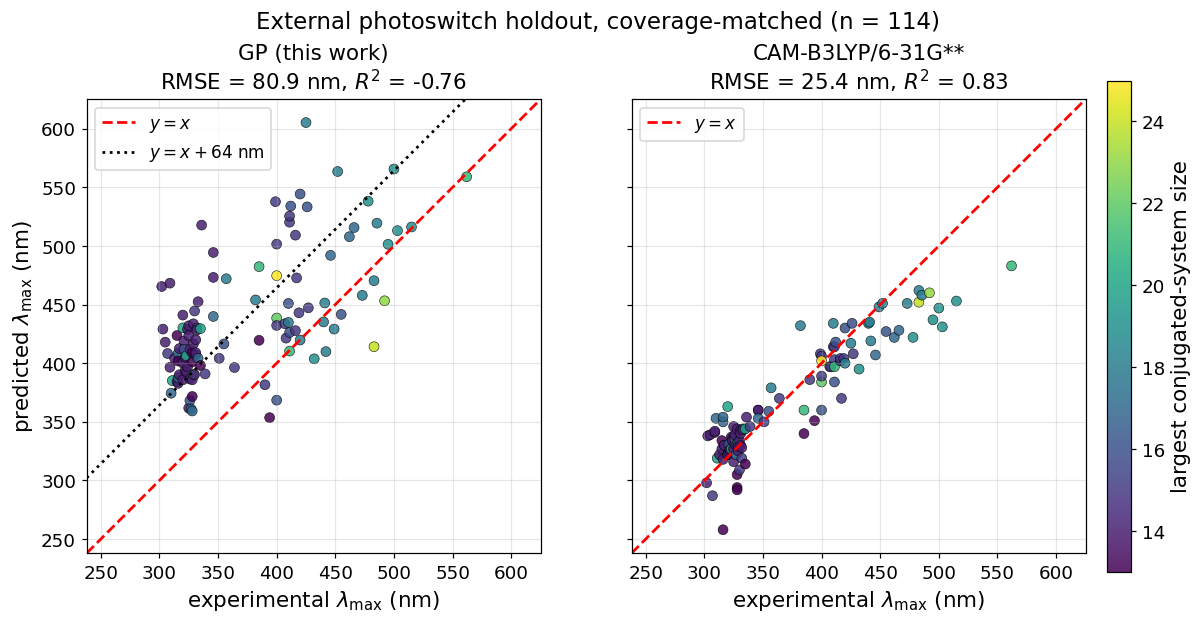

In [8]:
FIG_SUBSET = "CAM-B3LYP/6-31G**"
sub = df.dropna(subset=[DFT_COLS[FIG_SUBSET]])
y = sub["lambda_max_exp_nm"].to_numpy()
gp_p = sub["gp_pred"].to_numpy()
dft_p = sub[DFT_COLS[FIG_SUBSET]].to_numpy()
gp_bias = float(np.mean(gp_p - y))

lo = float(min(y.min(), gp_p.min(), dft_p.min())) - 20
hi = float(max(y.max(), gp_p.max(), dft_p.max())) + 20

fig, axes = plt.subplots(1, 2, figsize=(12.4, 5.8), sharex=True, sharey=True)
panels = (
    (axes[0], gp_p, f"GP (this work)\nRMSE = {metrics(y, gp_p)['rmse']:.1f} nm, "
                    f"$R^2$ = {metrics(y, gp_p)['r2']:.2f}", True),
    (axes[1], dft_p, f"{FIG_SUBSET}\nRMSE = {metrics(y, dft_p)['rmse']:.1f} nm, "
                     f"$R^2$ = {metrics(y, dft_p)['r2']:.2f}", False),
)
for ax, pred, title, show_shift in panels:
    sc = ax.scatter(
        y, pred, c=sub["LargestConjugatedSystemSize"], cmap="viridis",
        s=42, alpha=0.85, edgecolor="k", linewidth=0.4,
    )
    ax.plot([lo, hi], [lo, hi], "r--", lw=1.8, label="$y=x$")
    if show_shift:
        ax.plot([lo, hi], [lo + gp_bias, hi + gp_bias], "k:", lw=1.8,
                label=f"$y=x{gp_bias:+.0f}$ nm")
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_aspect("equal")
    ax.set_xlabel(r"experimental $\lambda_{\max}$ (nm)")
    ax.set_title(title)
    ax.legend(loc="upper left", frameon=True)
axes[0].set_ylabel(r"predicted $\lambda_{\max}$ (nm)")
cb = fig.colorbar(sc, ax=axes, fraction=0.035, pad=0.02)
cb.set_label("largest conjugated-system size")
fig.suptitle(
    f"External photoswitch holdout, coverage-matched (n = {len(sub)})",
    fontsize=15, y=0.99,
)
fig.savefig("fig_external_gp_vs_dft_parity.png", bbox_inches="tight")
print(f"saved fig_external_gp_vs_dft_parity.png   (n = {len(sub)}, GP bias = {gp_bias:+.1f} nm)")
plt.show()

**Figure 2 — total error against the error remaining once each offset is removed**

Solid bars are RMSE; hatched bars are `rmse_debiased`, the scatter that survives after a
method's constant offset is removed for free. These are drawn as **grouped** rather than
stacked bars because RMSE, bias, and scatter combine in quadrature, so bias and scatter
segments would not sum to RMSE. The dashed line is the null model, predicting the subset
mean for every molecule.

saved fig_external_error_budget.png


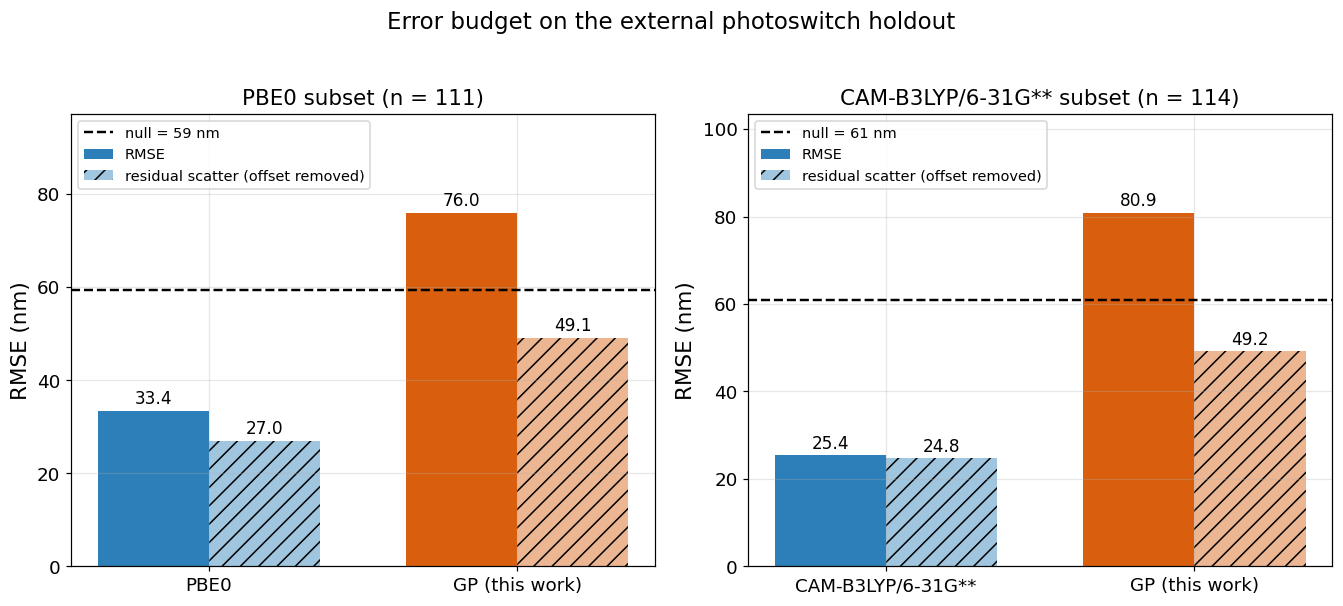

In [9]:
fig, axes = plt.subplots(1, len(USABLE), figsize=(6.2 * len(USABLE), 5.4), squeeze=False)
for ax, name in zip(axes[0], USABLE):
    rec = next(r for r in records if r["functional"] == name)
    labels = [name, "GP (this work)"]
    total = [rec["dft"]["rmse"], rec["gp"]["rmse"]]
    deb = [rec["dft"]["rmse_debiased"], rec["gp"]["rmse_debiased"]]
    colours = ["#2c7fb8", "#d95f0e"]
    xs = np.arange(len(labels))
    width = 0.36
    ax.bar(xs - width / 2, total, width, color=colours, label="RMSE")
    ax.bar(xs + width / 2, deb, width, color=colours, alpha=0.45, hatch="//",
           label="residual scatter (offset removed)")
    ax.axhline(rec["gp"]["null_rmse"], ls="--", c="k", lw=1.6,
               label=f"null = {rec['gp']['null_rmse']:.0f} nm")
    for x, (t, d) in enumerate(zip(total, deb)):
        ax.text(x - width / 2, t + 1.5, f"{t:.1f}", ha="center", fontsize=11)
        ax.text(x + width / 2, d + 1.5, f"{d:.1f}", ha="center", fontsize=11)
    ax.set_xticks(xs)
    ax.set_xticklabels(labels)
    ax.set_ylabel("RMSE (nm)")
    ax.set_title(f"{name} subset (n = {rec['dft']['n']})")
    ax.set_ylim(0, max(total) * 1.28)
    ax.legend(loc="upper left", fontsize=9.5)
fig.suptitle("Error budget on the external photoswitch holdout", fontsize=15, y=1.02)
fig.tight_layout()
fig.savefig("fig_external_error_budget.png", bbox_inches="tight")
print("saved fig_external_error_budget.png")
plt.show()

**GP predictive uncertainty on the external set**

The manuscript reports GP predictive standard deviations as a usable confidence signal. On
the external holdout the relevant question is whether $\sigma$ rises for the molecules the
model gets wrong. The Pearson correlation between $|\text{error}|$ and $\sigma$ answers it,
and the binned table shows whether the highest-$\sigma$ decile is in fact the least accurate.

In [10]:
err = np.abs(df["gp_pred"].to_numpy() - y_all)
sig = df["gp_std"].to_numpy()
calib_r = float(np.corrcoef(err, sig)[0, 1])

print("=== GP predictive uncertainty, external holdout (n=318) ===")
print(f"mean sigma            = {sig.mean():.2f} nm")
print(f"std of sigma          = {sig.std():.2f} nm")
print(f"mean |error|          = {err.mean():.2f} nm")
print(f"corr(|error|, sigma)  = {calib_r:+.3f}")
print(
    "\nFor reference the in-distribution random-split calibration correlation was +0.059,"
    "\nand the scaffold-split value was -0.030. All three are indistinguishable from zero."
)

qs = pd.qcut(sig, 4, labels=["Q1 (lowest sigma)", "Q2", "Q3", "Q4 (highest sigma)"])
binned = (
    pd.DataFrame({"quartile": qs, "abs_error": err, "sigma": sig})
    .groupby("quartile", observed=True)
    .agg(n=("abs_error", "size"), mean_sigma=("sigma", "mean"),
         mean_abs_error=("abs_error", "mean"))
)
print("\n=== Does higher predicted sigma identify worse predictions? ===")
print(binned.to_string(float_format=lambda v: f"{v:8.2f}"))
print(
    "\nA calibrated model would show mean_abs_error increasing down this table."
)

=== GP predictive uncertainty, external holdout (n=318) ===
mean sigma            = 100.63 nm
std of sigma          = 12.52 nm
mean |error|          = 64.79 nm
corr(|error|, sigma)  = -0.019

For reference the in-distribution random-split calibration correlation was +0.059,
and the scaffold-split value was -0.030. All three are indistinguishable from zero.

=== Does higher predicted sigma identify worse predictions? ===
                     n  mean_sigma  mean_abs_error
quartile                                          
Q1 (lowest sigma)   80       84.80           70.59
Q2                  79       96.38           57.87
Q3                  79      104.36           65.11
Q4 (highest sigma)  80      116.98           65.50

A calibrated model would show mean_abs_error increasing down this table.


**Interpretation**

Read the numeric output above rather than this cell for the values. The structural
conclusions this notebook supports are:

1. On the external photoswitch holdout, the two interpretable levels of theory are
   substantially more accurate than the published GP, and the gap persists after the GP's
   systematic offset is removed for free. The manuscript's "GP outperforms TD-DFT" claim
   does not survive external validation.
2. The reversal is explained by label definition, not by model capability. The Beard
   benchmark labels are heterogeneous text-mined $\lambda_{\max}$ values of unspecified
   transition character, which penalises a method that computes one specific transition.
   The Griffiths labels are a single defined transition matched to the theory values, which
   penalises a model trained to predict "some reported $\lambda_{\max}$".
3. GP predictive uncertainty is uninformative in every regime tested — random split,
   scaffold split, and external class — so the model carries no internal warning that it
   has left its applicability domain.
4. TD-DFT coverage is partial (roughly a third of the holdout) and uneven across
   functionals, so these are subset comparisons and must be reported with explicit $n$.

**Prior work that must be cited.** This holdout and its DFT columns come from Griffiths,
Greenfield, Thawani, Fuchter, Lee *et al.*, "Data-driven discovery of molecular
photoswitches with multioutput Gaussian processes", *Chem. Sci.* **2022**, 13, 13541–13551.
That study applied Gaussian processes to this dataset in-domain and compared against
TD-DFT. The present analysis asks a different question — whether a model trained on a
large heterogeneous literature corpus *transfers* to that class — but the overlap is close
enough that the citation is mandatory.

In [11]:
out: dict[str, Any] = {
    "holdout_n": int(len(df)),
    "gp_full_holdout": gp_full,
    "coverage": coverage.to_dict(orient="records"),
    "usable_functionals": USABLE,
    "comparisons": {r["functional"]: {"dft": r["dft"], "gp_matched": r["gp"]} for r in records},
    "uncertainty": {
        "mean_sigma": float(sig.mean()),
        "std_sigma": float(sig.std()),
        "mean_abs_error": float(err.mean()),
        "calibration_pearson_r": calib_r,
    },
    "figures": [
        "fig_external_gp_vs_dft_parity.png",
        "fig_external_error_budget.png",
    ],
}
Path("_external_dft_benchmark.json").write_text(json.dumps(out, indent=2))
print("saved _external_dft_benchmark.json")

cols = ["canonical_smi", "inchikey_nostereo", "lambda_max_exp_nm", "gp_pred", "gp_std",
        *DFT_COLS.values()]
df[cols].to_csv("external_gp_vs_dft_predictions.csv", index=False)
print("saved external_gp_vs_dft_predictions.csv")

saved _external_dft_benchmark.json
saved external_gp_vs_dft_predictions.csv
